# <font color='black'>Регрессионный анализ: панельные данные и каузальность, 2026 </font>
## <font color='black'> Практическое занятие 7. Мэтчинг </font>

Источник данных: Bauer P.C. (2015) Negative Experiences and Trust:
A Causal Analysis of the Effects of Victimization on Generalized Trust.
European Sociological Review, Vol. 31, No. 4, pp. 397 - 417.

Ниже представлено краткое описание данных:

* Зависимая переменная: y_trust2008 - уровень обобщенного доверия
Would you say that most people can be trusted or that you can’t
be too careful in dealing with people, if 0 means “Can’t be too careful” and
10 means “Most people can be trusted”?

* Ключевой предиктор: d_threat2008
Have you been insulted or threatened verbally since (month, year)?
Дамми-переменная: 1 - reported an insult or threat; 0 - otherwise

* Контрольная переменная: x_male2008 (1 - male; 0 - female)

* Контрольная переменная: x_education2008
Порядковая шкала: level of education from 0 - the lowest level to 10 - the highest level of education

* Контрольная переменная: x_income2008
Порядковая шкала: level of income from 0 - the poorest households to 3 - the wealthiest households


Откроем массив и оставим только необходимые для анализа переменные:

In [115]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
!pip install tableone
from tableone import TableOne
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

In [116]:
labdata = pd.read_csv("matching_lab.csv")
datashort = labdata[['y_trust2008', 'd_threat2008', 'x_male2008', 'x_age2008', 'x_education2008', 'x_income2008']].dropna()

datashort.head()

,y_trust2008,d_threat2008,x_male2008,x_age2008,x_education2008,x_income2008
0,4.0,1.0,1.0,43.0,8.0,3.0
5,2.0,0.0,1.0,47.0,10.0,3.0
18,8.0,0.0,0.0,40.0,1.0,0.0
19,2.0,1.0,1.0,40.0,4.0,3.0
25,7.0,0.0,0.0,43.0,5.0,3.0


Оценим предварительную модель m1 на исходных данных, пока без применения мэтчинга

In [117]:
m1 = smf.ols('y_trust2008 ~ d_threat2008 + x_male2008 + x_age2008 + x_education2008 + x_income2008', data=datashort).fit(cov_type = "HC3")
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:            y_trust2008   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     43.82
Date:                Mon, 11 May 2026   Prob (F-statistic):           2.71e-44
Time:                        21:20:31   Log-Likelihood:                -10098.
No. Observations:                4630   AIC:                         2.021e+04
Df Residuals:                    4624   BIC:                         2.025e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           5.5835      0.112     

Проверим, есть ли баланс в распределениях контрольных переменных между группой воздействия и контрольной группой

In [118]:
table1 = TableOne(data=datashort,
                  columns=['x_male2008', 'x_age2008', 'x_education2008', 'x_income2008'],
                  groupby='d_threat2008',
                  categorical=['x_male2008', 'x_income2008'],
                  smd=True, missing = False, decimals = 3
                  )

print(table1)

                               Grouped by d_threat2008                                                
                                               Overall              0.0              1.0 SMD (0.0,1.0)
n                                                 4630             4092              538              
x_male2008, n (%)          0.0           2412 (52.095)    2177 (53.201)     235 (43.680)         0.191
                           1.0           2218 (47.905)    1915 (46.799)     303 (56.320)              
x_age2008, mean (SD)                   41.701 (14.328)  42.565 (14.086)  35.130 (14.456)        -0.521
x_education2008, mean (SD)               5.519 (3.019)    5.587 (2.989)    5.004 (3.195)        -0.188
x_income2008, n (%)        0.0           1335 (28.834)    1133 (27.688)     202 (37.546)         0.217
                           1.0           1174 (25.356)    1057 (25.831)     117 (21.747)              
                           2.0            876 (18.920)     779 (19.037)  

Дополнительно выведем результаты тестирования равенства дисперсий для интервальных/псевдо-интервальных переменных:

In [119]:
levene_test_data = {"Variable": [], "Levene's test statistic": [], "p-value": []}

for col in ['x_age2008', 'x_education2008']:
    group1 = datashort[datashort['d_threat2008'] == 0][col].dropna()
    group2 = datashort[datashort['d_threat2008'] == 1][col].dropna()
    f_stat, p_val = stats.levene(group1, group2)
    levene_test_data["Variable"].append(col)
    levene_test_data["Levene's test statistic"].append(f_stat)
    levene_test_data["p-value"].append(p_val)

levene_test_data = pd.DataFrame(levene_test_data)

levene_test_data

,Variable,Levene's test statistic,p-value
0,x_age2008,9.443476,0.002131
1,x_education2008,0.908907,0.340455


Проверим, соблюдается ли допущение common support:

In [120]:
m_logit = smf.logit(formula='d_threat2008 ~ x_male2008 + x_age2008 + x_education2008 + x_income2008',
               data=datashort).fit(cov_type = "HC3")

print(m_logit.summary())

Optimization terminated successfully.
         Current function value: 0.343019
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           d_threat2008   No. Observations:                 4630
Model:                          Logit   Df Residuals:                     4625
Method:                           MLE   Df Model:                            4
Date:                Mon, 11 May 2026   Pseudo R-squ.:                 0.04527
Time:                        21:20:33   Log-Likelihood:                -1588.2
converged:                       True   LL-Null:                       -1663.5
Covariance Type:                  HC3   LLR p-value:                 1.517e-31
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.8150      0.145     -5.603      0.000      -1.100      -0.530
x_male2008    

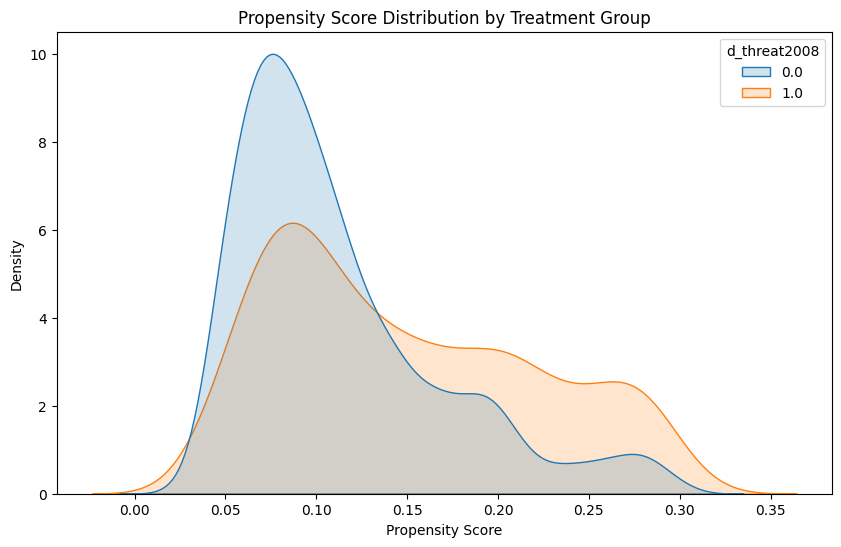

In [121]:
datashort['pscore'] = m_logit.predict()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=datashort, x='pscore', hue='d_threat2008',
                fill=True, alpha=0.2, common_norm=False,
                legend=True)

plt.title('Propensity Score Distribution by Treatment Group')
plt.xlabel('Propensity Score')
plt.ylabel('Density')

plt.show()

Применим мэтчинг со следующими параметрами:

1) метод ближайшего соседа

2) 1:1

3) расстояние Махаланобиса

In [122]:
X = datashort[['x_male2008', 'x_age2008', 'x_education2008', 'x_income2008']]
y = datashort['d_threat2008']

treated = X[y == 1]
control = X[y == 0]

nbrs = NearestNeighbors(
    n_neighbors=1,
    metric='mahalanobis',
    metric_params={'VI': np.linalg.inv(np.cov(X.T))}
).fit(control)

distances, indices = nbrs.kneighbors(treated)

matched_control = datashort[y == 0].iloc[indices.flatten()]
matched_treated = datashort[y == 1]
matched_data = pd.concat([matched_treated, matched_control])

matched_data

,y_trust2008,d_threat2008,x_male2008,x_age2008,x_education2008,x_income2008,pscore
0,4.0,1.0,1.0,43.0,8.0,3.0,0.113333
19,2.0,1.0,1.0,40.0,4.0,3.0,0.126136
113,3.0,1.0,1.0,19.0,0.0,0.0,0.267488
165,3.0,1.0,1.0,49.0,4.0,0.0,0.112752
169,7.0,1.0,0.0,45.0,7.0,3.0,0.069997
...,...,...,...,...,...,...,...
5002,3.0,0.0,1.0,23.0,1.0,0.0,0.240449
12539,6.0,0.0,1.0,28.0,9.0,0.0,0.204441
7998,8.0,0.0,1.0,39.0,4.0,1.0,0.144508
16911,0.0,0.0,1.0,26.0,4.0,0.0,0.219713


In [123]:
matched_data = matched_data.reset_index(drop=True)

table1_after_matching = TableOne(data=matched_data,
                  columns=['x_male2008', 'x_age2008', 'x_education2008', 'x_income2008'],
                  groupby='d_threat2008',
                  categorical=['x_male2008', 'x_income2008'], missing = False,
                  smd=True, decimals = 3
                  )

print(table1_after_matching)

                               Grouped by d_threat2008                                                
                                               Overall              0.0              1.0 SMD (0.0,1.0)
n                                                 1076              538              538              
x_male2008, n (%)          0.0            470 (43.680)     235 (43.680)     235 (43.680)        <0.001
                           1.0            606 (56.320)     303 (56.320)     303 (56.320)              
x_age2008, mean (SD)                   35.138 (14.405)  35.147 (14.368)  35.130 (14.456)        -0.001
x_education2008, mean (SD)               5.003 (3.194)    5.002 (3.197)    5.004 (3.195)         0.001
x_income2008, n (%)        0.0            404 (37.546)     202 (37.546)     202 (37.546)        <0.001
                           1.0            234 (21.747)     117 (21.747)     117 (21.747)              
                           2.0            194 (18.030)      97 (18.030)  

In [124]:
y_treated = matched_data.loc[matched_data['d_threat2008'] == 1, 'y_trust2008']
y_control = matched_data.loc[matched_data['d_threat2008'] == 0, 'y_trust2008']

t_stat, p_value = stats.ttest_ind(y_treated, y_control, equal_var=False)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: -2.9818
p-value: 0.0029


Переоценим модель на полученном массиве:

In [125]:
m1_matched = smf.ols('y_trust2008 ~ d_threat2008', data=matched_data).fit(cov_type = "HC3")
print(m1_matched.summary())

                            OLS Regression Results                            
Dep. Variable:            y_trust2008   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     8.874
Date:                Mon, 11 May 2026   Prob (F-statistic):            0.00296
Time:                        21:20:39   Log-Likelihood:                -2388.2
No. Observations:                1076   AIC:                             4780.
Df Residuals:                    1074   BIC:                             4790.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        6.1803      0.088     69.912   

Реализуем мэтчинг на основании propensity score в качестве метрики. Добавим также caliper - пороговое значение, которое нельзя превышать при объединении объектов в "пары"

In [126]:
X = datashort[['x_male2008', 'x_age2008', 'x_education2008', 'x_income2008']]
y = datashort['d_threat2008']

treated = datashort[y == 1]
control = datashort[y == 0]

nbrs_2 = NearestNeighbors(n_neighbors=1).fit(control[['pscore']].values)

distances_2, indices_2 = nbrs_2.kneighbors(treated[['pscore']].values)

caliper = 0.2 * np.std(datashort['pscore'])
matches_2 = distances_2.flatten() <= caliper

matched_treated_2 = treated.iloc[np.where(matches_2)[0]]
matched_control_2 = control.iloc[indices_2[matches_2].flatten()]

matched_data_2 = pd.concat([matched_treated_2, matched_control_2])

matched_data_2

,y_trust2008,d_threat2008,x_male2008,x_age2008,x_education2008,x_income2008,pscore
0,4.0,1.0,1.0,43.0,8.0,3.0,0.113333
19,2.0,1.0,1.0,40.0,4.0,3.0,0.126136
113,3.0,1.0,1.0,19.0,0.0,0.0,0.267488
165,3.0,1.0,1.0,49.0,4.0,0.0,0.112752
169,7.0,1.0,0.0,45.0,7.0,3.0,0.069997
...,...,...,...,...,...,...,...
21202,7.0,0.0,1.0,20.0,4.0,2.0,0.234617
2397,8.0,0.0,1.0,21.0,5.0,2.0,0.227679
7998,8.0,0.0,1.0,39.0,4.0,1.0,0.144508
5379,5.0,0.0,1.0,24.0,0.0,2.0,0.213662


In [127]:
matched_data_2 = matched_data_2.reset_index(drop=True)

table2_after_matching = TableOne(data=matched_data_2,
                  columns=['x_male2008', 'x_age2008', 'x_education2008', 'x_income2008'],
                  groupby='d_threat2008',
                  categorical=['x_male2008', 'x_income2008'], missing = False,
                  smd=True, decimals = 3
                  )

print(table2_after_matching)

                               Grouped by d_threat2008                                                
                                               Overall              0.0              1.0 SMD (0.0,1.0)
n                                                 1076              538              538              
x_male2008, n (%)          0.0            465 (43.216)     230 (42.751)     235 (43.680)         0.019
                           1.0            611 (56.784)     308 (57.249)     303 (56.320)              
x_age2008, mean (SD)                   35.178 (14.559)  35.227 (14.674)  35.130 (14.456)        -0.007
x_education2008, mean (SD)               4.972 (3.210)    4.941 (3.228)    5.004 (3.195)         0.020
x_income2008, n (%)        0.0            399 (37.082)     197 (36.617)     202 (37.546)         0.021
                           1.0            236 (21.933)     119 (22.119)     117 (21.747)              
                           2.0            194 (18.030)      97 (18.030)  

Сопоставим результаты с оптимальным мэтчингом

In [128]:
X = datashort[['x_male2008', 'x_age2008', 'x_education2008', 'x_income2008']]
y = datashort['d_threat2008']

treated = X[y == 1]
control = X[y == 0]

dist_matrix = cdist(treated, control, metric='mahalanobis', VI=np.linalg.pinv(np.cov(X.T)))

treated_index, control_index = linear_sum_assignment(dist_matrix)

matched_treated_3 = datashort[y == 1].iloc[treated_index]
matched_control_3 = datashort[y == 0].iloc[control_index]
matched_data_3 = pd.concat([matched_treated_3, matched_control_3], ignore_index=True)

In [129]:
matched_data_3 = matched_data_3.reset_index(drop=True)

table3_after_matching = TableOne(data=matched_data_3,
                  columns=['x_male2008', 'x_age2008', 'x_education2008', 'x_income2008'],
                  groupby='d_threat2008',
                  categorical=['x_male2008', 'x_income2008'],
                  smd=True, decimals = 3, missing = False
                  )

print(table3_after_matching)

                               Grouped by d_threat2008                                                
                                               Overall              0.0              1.0 SMD (0.0,1.0)
n                                                 1076              538              538              
x_male2008, n (%)          0.0            470 (43.680)     235 (43.680)     235 (43.680)        <0.001
                           1.0            606 (56.320)     303 (56.320)     303 (56.320)              
x_age2008, mean (SD)                   35.180 (14.460)  35.230 (14.478)  35.130 (14.456)        -0.007
x_education2008, mean (SD)               5.004 (3.196)    5.004 (3.200)    5.004 (3.195)        <0.001
x_income2008, n (%)        0.0            404 (37.546)     202 (37.546)     202 (37.546)        <0.001
                           1.0            234 (21.747)     117 (21.747)     117 (21.747)              
                           2.0            194 (18.030)      97 (18.030)  